# 617 Project – NYISO Load Forecasting (Group 3)

This notebook documents the reproducible steps, metrics, and plots for our NYISO load + weather forecasting using LSTM baseline and Temporal Fusion Transformer (TFT). All paths are relative to the repo root.

## 1. Environment
- Python 3.12 (recommend virtualenv .venv)
- Install deps:

```bash
pip install -r requirements.txt
```

(Optional) use GPU for TFT: set `--device cuda` in eval/training.

## 2. Data
- Config: `src/config.yaml` (timezone America/New_York, splits, quantiles, extreme thresholds).
- Processed file: `data/processed/all.parquet` (created by `scripts/data_pull.py`).
- To refresh data (optional):
```bash
python scripts/data_pull.py --force --refresh-weather
```


In [2]:
import os
os.chdir("/home/salehin/617-project")


In [3]:
import pandas as pd
from pathlib import Path

df = pd.read_parquet('data/processed/all.parquet')
print(df.head())
print('Range:', df.ds.min(), '->', df.ds.max(), 'rows:', len(df))

                         ds        y  temp  dwpt  prcp  holiday  extreme_flag
0 2019-01-01 00:00:00-05:00  15774.0   8.1   7.4   4.6        1             0
1 2019-01-01 01:00:00-05:00  15053.0   8.9   8.6   2.0        1             0
2 2019-01-01 02:00:00-05:00  14481.0   9.4   8.9   0.5        1             0
3 2019-01-01 03:00:00-05:00  13927.0  11.1  10.5   0.4        1             0
4 2019-01-01 04:00:00-05:00  13566.0  12.8  11.8   0.0        1             0
Range: 2019-01-01 00:00:00-05:00 -> 2026-03-17 23:00:00-04:00 rows: 63177


## 3. Splits
From `config.yaml`: train_end=2023-12-31, val_end=2024-12-31, test=2025+ (tz-aware).

## 4. LSTM baseline (summary)
- Lookback 7 days, horizon 24, quantile loss.
- Metrics (normalized units): MAE 0.279, RMSE 0.422, MAPE 2.26%, pinball 0.091.
- Checkpoint: see `reports/lstm_baseline/` if retraining is needed.


## 5. TFT (trained 15 epochs)
- Lookback 336, horizon 24, GroupNormalizer, allow_missing_timesteps=True.
- Checkpoint: `reports/tft/lightning_logs/version_3/checkpoints/epoch=14-step=10170.ckpt`.
- Metrics (denormalized): MAE 835.803, RMSE 1289.662, MAPE 6.20%, pinball 585.909 (samples=245,832).
- Eval command used:
```bash
python scripts/eval_tft.py --checkpoint reports/tft/lightning_logs/version_3/checkpoints/epoch=14-step=10170.ckpt --device cuda --batch_size 256 --num_workers 0
```


In [4]:
import yaml
from pathlib import Path
metrics = yaml.safe_load(Path('reports/tft/metrics.yaml').read_text())
metrics

{'mae': 835.802734375,
 'mape_pct': 6.2002576887607574,
 'pinball': 585.9090576171875,
 'rmse': 1289.6622314453125,
 'samples': 245832}

## 6. Plots (generated by `scripts/report_plots.py`)


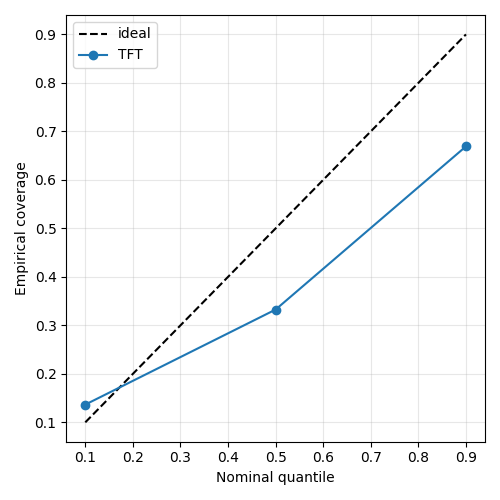

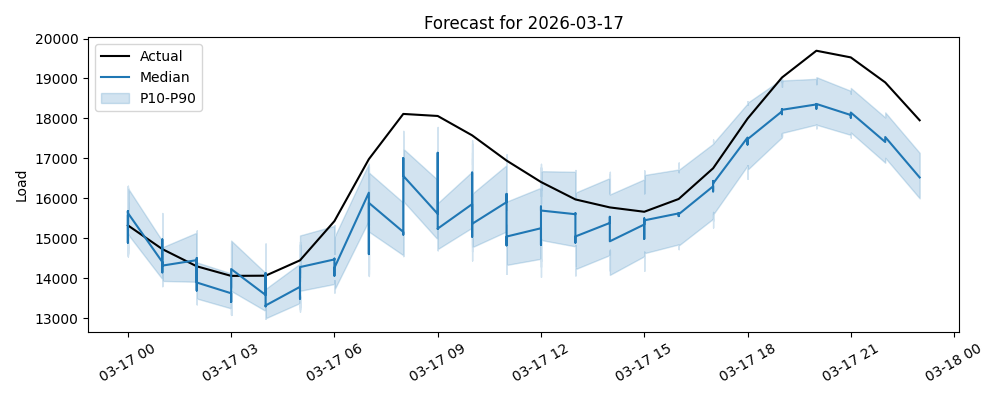

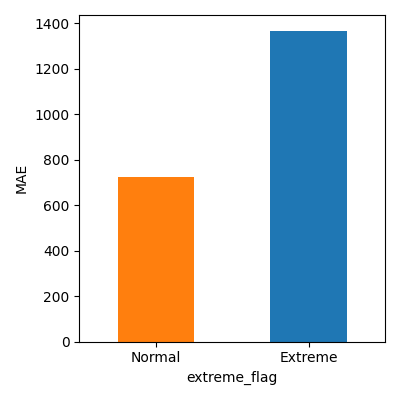

In [5]:
from IPython.display import Image, display
for fname in ['calibration_tft.png', 'sample_day_tft.png', 'extreme_mae_tft.png']:
    display(Image(filename=f'reports/{fname}'))

## 7. Comparison table


In [6]:
from pathlib import Path
print(Path('reports/comparison.md').read_text())

# Model Comparison

| Model | MAE | RMSE | MAPE | Pinball | Notes |
| --- | --- | --- | --- | --- | --- |
| LSTM baseline | 0.279 | 0.422 | 2.26% | 0.091 | normalized units; horizon 24 |
| TFT (15 epochs) | 835.803 | 1289.662 | 6.20% | 585.909 | horizon 24, lookback 336; metrics from reports/tft/metrics.yaml |


## 8. Reproduce end-to-end
```bash
source .venv/bin/activate
python scripts/data_pull.py --force --refresh-weather
python scripts/train_tft.py --max_epochs 15
python scripts/eval_tft.py --checkpoint reports/tft/lightning_logs/version_3/checkpoints/epoch=14-step=10170.ckpt --device cuda --batch_size 256 --num_workers 0
python scripts/report_plots.py
```


## 9. Notes / gotchas
- ds is tz-aware; time_idx is hours since epoch.
- TFT predictions from pytorch-forecasting are already denormalized.
- MAPE denominator clamped in eval to avoid tiny-target blowups.
- GPU recommended for speed; otherwise lower batch_size.
- Weather cached; use `--refresh-weather` only when needed.
